# TinyStories GPT

In this work, I study the design of Karpathy’s nanoGPT and build my own GPT-style language model from scratch in this Jupyter notebook. The purpose is to understand the main components of a modern autoregressive language model by reimplementing them myself.

This notebook has three sections:

1. **Implement a minimal GPT model**: A pure-PyTorch `nn.Module`s for self-attention, a transformer block, and the full model, with KV caching for inference.
2. **Implement the training pipeline**: AdamW + cosine schedule with warmup, gradient accumulation, gradient clipping, mixed-precision (bfloat16) training, validation, and early stopping.
3. **Train on a small text dataset and evaluate qualitatively**: BPE tokenization with `tiktoken`, loss curves, and sampled text with temperature and top-k.

**Dependencies.** PyTorch ≥ 2.1 (for native bf16 autocast), `tiktoken`, `numpy`, `matplotlib`, and `datasets`.

In [1]:
import math
import time
import os
import inspect
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)
np.random.seed(1337)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype  = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float32
print(f"Using device: {device}")
print(f"Autocast dtype: {dtype}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
Autocast dtype: torch.bfloat16
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.5 GB


---
## 1. Minimal GPT Model Implementation

We build a **decoder-only transformer** in the style of GPT-2. The data flow is:

```
tokens (B, T)
   │
   ├── token embedding  (V → D)
   └── positional embedding (T → D)   ← learned absolute
   │
   ▼
[ Transformer Block ] × L
   │   ┌─ LayerNorm → Multi-Head Self-Attention (causal) ─┐
   │   │                   ↓                               │
   │   └─────────── residual add ──────────────────────────┘
   │   ┌─ LayerNorm → MLP (D → 4D → D, GELU) ─────────────┐
   │   │                   ↓                               │
   │   └─────────── residual add ──────────────────────────┘
   │
   ▼
final LayerNorm  →  Linear (D → V)  →  logits
```

**Pre-norm** means `LayerNorm` is applied *before* attention and the MLP — more stable than post-norm for deep stacks.

### Configuration

The model targets **~30M parameters**:

| Hyperparameter | Value |
|---|---|
| Layers (`n_layer`) | 6 |
| Heads (`n_head`) | 6 |
| Embedding dim (`n_embd`) | 384 |
| Context length (`block_size`) | 256 |
| Vocab size (`vocab_size`) | 50,257 (GPT-2 BPE) |
| Dropout | 0.1 |

The head dimension remains 64 (`384 / 6 = 64`), exactly matching GPT-2 small's per-head dim, so every implementation detail of multi-head attention is identical — we just use fewer heads and a narrower embedding.

In [2]:
@dataclass
class GPTConfig:
    block_size: int = 256        # max context length
    vocab_size: int = 50257      # GPT-2 BPE vocabulary
    n_layer:    int = 6          # transformer depth
    n_head:     int = 6          # attention heads
    n_embd:     int = 384        # embedding width
    dropout:    float = 0.1
    bias:       bool = True      # bias in Linears and LayerNorms

### 1.1 Causal self-attention with KV caching

Multi-head self-attention computes, for each head,
$$\text{Attn}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right) V,$$
where $M$ is a causal mask that sets upper-triangular entries (future positions) to $-\infty$.

**Implementation notes.**

- Q, K, V are computed in a single fused `Linear(n_embd, 3 * n_embd)` projection — saves one kernel launch.
- `F.scaled_dot_product_attention` (SDPA) dispatches to FlashAttention on modern GPUs with `is_causal=True`.
- **KV caching for inference.** Cached keys/values from prior tokens are reused on each generation step, turning $O(T^2)$ re-computation into $O(T)$ per step. The cache is *strictly for inference*; `use_cache=False` during training.

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head   = config.n_head
        self.n_embd   = config.n_embd
        self.head_dim = config.n_embd // config.n_head
        self.dropout  = config.dropout

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout  = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        self.c_proj.RESIDUAL_PROJECTION = True

        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
                 .view(1, 1, config.block_size, config.block_size),
            persistent=False,
        )

    def forward(
        self,
        x: torch.Tensor,
        kv_cache: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
        use_cache: bool = False,
    ):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        if use_cache and kv_cache is not None:
            past_k, past_v = kv_cache
            k = torch.cat([past_k, k], dim=2)
            v = torch.cat([past_v, v], dim=2)
        new_cache = (k, v) if use_cache else None

        if use_cache and kv_cache is not None:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=0.0, is_causal=False)
        else:
            y = F.scaled_dot_product_attention(
                q, k, v, attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True,
            )

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y, new_cache


### 1.2 Feed-forward MLP

A two-layer MLP that expands the hidden dim by 4× and uses **GELU** (the nonlinearity GPT-2 uses). The second linear is a "residual projection" that receives the scaled-down init.

In [4]:
class MLP(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU(approximate='tanh')
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
        self.c_proj.RESIDUAL_PROJECTION = True

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


### 1.3 Transformer block (pre-norm)

Each block is two residual sub-layers:
$$x \leftarrow x + \text{Attn}(\text{LN}_1(x)), \quad x \leftarrow x + \text{MLP}(\text{LN}_2(x)).$$

In [5]:
class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp  = MLP(config)

    def forward(self, x, kv_cache=None, use_cache=False):
        attn_out, new_cache = self.attn(self.ln_1(x), kv_cache=kv_cache, use_cache=use_cache)
        x = x + attn_out
        x = x + self.mlp(self.ln_2(x))
        return x, new_cache

### 1.4 The full GPT model

Putting it all together:

- **Token embedding** `wte`: lookup table `V × D`.
- **Positional embedding** `wpe`: learned lookup table `block_size × D` (absolute, as in GPT-2).
- A stack of `n_layer` transformer blocks.
- A final `LayerNorm`.
- **LM head**: `Linear(D, V)`. We **tie** its weights to the token embedding, saving `V × D` parameters and improving generalization.

**Weight initialization** follows GPT-2:

- All `Linear` and `Embedding` weights: $\mathcal{N}(0, 0.02^2)$, biases zero.
- **Residual projections** (`c_proj` in attention and MLP) get their std scaled by $1/\sqrt{2L}$, preventing the residual stream from growing with depth.

**KV cache semantics** `use_cache=True` for inference, `use_cache=False` for training.

In [6]:
class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying: token embedding ↔ LM head
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)
        # Residual projections get scaled init: std = 0.02 / sqrt(2 * n_layer)
        for name, p in self.named_parameters():
            if name.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

        print(f"Number of parameters: {self.num_params() / 1e6:.2f}M")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def num_params(self, non_embedding: bool = True):
        n = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n -= self.transformer.wpe.weight.numel()
        return n

    def forward(
        self,
        idx: torch.Tensor,
        targets: Optional[torch.Tensor] = None,
        past_kv: Optional[list] = None,
        use_cache: bool = False,
    ):
        B, T = idx.size()
        past_length = 0
        if past_kv is not None and past_kv[0] is not None:
            past_length = past_kv[0][0].size(2)
        assert past_length + T <= self.config.block_size, \
            f"Sequence of length {past_length + T} exceeds block_size={self.config.block_size}"

        pos     = torch.arange(past_length, past_length + T, dtype=torch.long, device=idx.device)
        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)

        new_past = [] if use_cache else None
        if past_kv is None:
            past_kv = [None] * self.config.n_layer
        for block, layer_past in zip(self.transformer.h, past_kv):
            x, new_layer_past = block(x, kv_cache=layer_past, use_cache=use_cache)
            if use_cache:
                new_past.append(new_layer_past)

        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )
            return logits, loss
        else:
            logits = self.lm_head(x[:, -1:, :])
            return logits, new_past

    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        use_cache: bool = True,
    ):
        """Autoregressively sample tokens. Uses KV caching by default."""
        self.eval()
        past_kv   = None
        cur_input = idx
        for _ in range(max_new_tokens):
            if cur_input.size(1) > self.config.block_size:
                cur_input = cur_input[:, -self.config.block_size:]
                past_kv   = None

            logits, past_kv = self(cur_input, past_kv=past_kv, use_cache=use_cache)
            logits = logits[:, -1, :] / max(temperature, 1e-6)

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('inf')

            probs      = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            idx        = torch.cat([idx, next_token], dim=1)

            cur_input = next_token if use_cache else idx
        return idx


### 1.5 Sanity check

Instantiate the model, count parameters, and run a forward pass on random tokens.  
At initialization the loss should be $\approx \log(50257) \approx 10.83$ — uniform probability over the vocabulary.

In [7]:
config = GPTConfig()
model  = GPT(config)

x = torch.randint(0, config.vocab_size, (2, 64))
y = torch.randint(0, config.vocab_size, (2, 64))
logits, loss = model(x, targets=y)
print(f"Logits shape: {logits.shape}")
print(f"Initial loss: {loss.item():.4f}  (expected ~{math.log(config.vocab_size):.2f} for uniform)")


Number of parameters: 29.95M
Logits shape: torch.Size([2, 64, 50257])
Initial loss: 10.8953  (expected ~10.82 for uniform)


---
## 2. Training Pipeline

> **Hardware and time estimates**
>
> The default `TrainConfig` below is sized for a **modest GPU or CPU**:
> - **GPU (any):** ~5–10 minutes
> - **CPU only:** ~30–60 minutes
>
> Every code path (data loading → forward → backward → eval → sampling) is exercised.
> Expect a final val loss around **2.0–2.5** on TinyStories and generated text that reads as simple, coherent English prose.

### 2.1 Data batching for next-token prediction

Language modeling is *self-supervised*: the target for position $t$ is the token at position $t+1$.

```
x = tokens[i     : i + T]        # input
y = tokens[i + 1 : i + T + 1]    # targets (x shifted by one)
```

We sample `batch_size` random starting indices per step — effectively sampling with replacement from all `T`-length windows.

In [8]:
def get_batch(tokens: np.ndarray, block_size: int, batch_size: int, device: str):
    """Sample a minibatch of (x, y) from a flat array of token ids."""
    ix = torch.randint(0, len(tokens) - block_size - 1, (batch_size,))
    x  = torch.from_numpy(np.stack([tokens[i     : i + block_size    ].astype(np.int64) for i in ix]))
    y  = torch.from_numpy(np.stack([tokens[i + 1 : i + 1 + block_size].astype(np.int64) for i in ix]))
    if device == 'cuda':
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

### 2.2 Training configuration

| Setting | value | Why |
|---|---|---|
| Optimizer | AdamW | Decoupled weight decay avoids shrinking biases & LayerNorm params |
| Peak LR | `3e-4` | Slightly higher than GPT-2 scale; smaller models tolerate larger LR |
| LR min | `3e-5` | 10× decay at end of cosine schedule |
| Warmup | 10% of total steps | Avoids early loss spike when Adam moments are unreliable |
| Schedule | Cosine after warmup | Smooth decay |
| $\beta_1, \beta_2$ | 0.9, 0.95 | GPT-2 / GPT-3 values |
| Weight decay | 0.1 | 2-D weights only |
| Grad clip | 1.0 | Prevents exploding-gradient spikes |
| Precision | bf16 autocast | Free ~2× speedup on modern GPUs |
| Micro-batch | 8 | Fits comfortably even in 4 GB VRAM at `block_size=256` |
| Global batch | ~16k tokens | `8 × 256 × 8 acc steps`; right-sized for a 10M model |
| Eval every | 100 steps | More frequent visibility at shorter training |
| Early stop | 3 non-improving evals | Or hard stop at 5,000 steps |

In [9]:
@dataclass
class TrainConfig:
    out_dir:              str   = 'out'
    eval_interval:        int   = 100
    eval_iters:           int   = 50
    early_stop_patience:  int   = 3
    block_size:           int   = 256
    learning_rate:        float = 3e-4
    weight_decay:         float = 0.1
    beta1:                float = 0.9
    beta2:                float = 0.95
    grad_clip:            float = 1.0
    max_iters:            int   = 2000
    warmup_frac:          float = 0.10
    min_lr:               float = 3e-5
    micro_batch_size:     int   = 8
    grad_accum_steps:     int   = 8   # global batch = 8 × 256 × 8 = 16,384 tokens/step
    dtype:                str   = 'bfloat16'
    compile_model:        bool  = True

tcfg = TrainConfig()
tokens_per_step = tcfg.micro_batch_size * tcfg.block_size * tcfg.grad_accum_steps
print(f"Tokens per optimizer step: {tokens_per_step:,}")


Tokens per optimizer step: 16,384


### 2.3 AdamW parameter groups and LR schedule

**Two parameter groups.** Weight decay applies to "matrix" parameters (Linear weights, embedding matrices) but *not* to 1-D parameters (biases, LayerNorm scales).

**Fused AdamW.** On CUDA, PyTorch offers a fused kernel — we opt in automatically if available.

**Cosine schedule with warmup.** With warmup steps $W = \lfloor 0.10 N \rfloor$:

$$\text{lr}(i) = \begin{cases}
\text{lr}_{\max} \cdot \dfrac{i+1}{W} & i < W \\[6pt]
\text{lr}_{\min} + \tfrac{1}{2}(\text{lr}_{\max} - \text{lr}_{\min})\left(1 + \cos\!\left(\pi \cdot \dfrac{i - W}{N - W}\right)\right) & i \ge W
\end{cases}$$

In [10]:
def configure_optimizer(model: nn.Module, tcfg: TrainConfig, device: str):
    seen_ids = set()
    decay_params, nodecay_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if id(p) in seen_ids:
            continue
        seen_ids.add(id(p))
        if p.dim() >= 2:
            decay_params.append(p)
        else:
            nodecay_params.append(p)

    optim_groups = [
        {'params': decay_params,   'weight_decay': tcfg.weight_decay},
        {'params': nodecay_params, 'weight_decay': 0.0},
    ]
    print(f"Decayed params: {sum(p.numel() for p in decay_params)/1e6:.2f}M  |  "
          f"non-decayed: {sum(p.numel() for p in nodecay_params)/1e6:.3f}M")

    fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
    use_fused = fused_available and device == 'cuda'
    extra = dict(fused=True) if use_fused else dict()
    optimizer = torch.optim.AdamW(
        optim_groups, lr=tcfg.learning_rate,
        betas=(tcfg.beta1, tcfg.beta2), **extra,
    )
    print(f"Fused AdamW: {use_fused}")
    return optimizer


def get_lr(step: int, tcfg: TrainConfig) -> float:
    warmup = int(tcfg.warmup_frac * tcfg.max_iters)
    if step < warmup:
        return tcfg.learning_rate * (step + 1) / warmup
    if step > tcfg.max_iters:
        return tcfg.min_lr
    decay_ratio = (step - warmup) / (tcfg.max_iters - warmup)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return tcfg.min_lr + coeff * (tcfg.learning_rate - tcfg.min_lr)


### 2.4 Evaluation helper

Estimate train/val loss over `eval_iters` random batches. Model is put in `eval()` (disables dropout) and wrapped in `torch.no_grad()`.

In [11]:
@torch.no_grad()
def estimate_loss(model, train_tokens, val_tokens, tcfg, device):
    out = {}
    model.eval()
    for split, data in [('train', train_tokens), ('val', val_tokens)]:
        losses = torch.zeros(tcfg.eval_iters)
        for k in range(tcfg.eval_iters):
            X, Y = get_batch(data, tcfg.block_size, tcfg.micro_batch_size, device)
            if device == 'cuda':
                with torch.amp.autocast(device_type='cuda', dtype=getattr(torch, tcfg.dtype)):
                    _, loss = model(X, targets=Y)
            else:
                _, loss = model(X, targets=Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

### 2.5 The training loop

The main steps:

1. **Set LR for this step** — update every param group's `lr`.
2. **Periodic evaluation** — every `eval_interval` steps, estimate train/val loss. Save checkpoint on improvement; early-stop if patience runs out.
3. **Gradient accumulation** — loop `grad_accum_steps` times: fetch micro-batch → forward under `autocast(bfloat16)` → divide loss by `grad_accum_steps` → `backward()`.
4. **Gradient clipping** — `clip_grad_norm_(..., 1.0)`.
5. **Optimizer step** — then `zero_grad(set_to_none=True)`.


In [12]:
from dataclasses import asdict

def train(model, train_tokens, val_tokens, tcfg, device):
    os.makedirs(tcfg.out_dir, exist_ok=True)
    optimizer = configure_optimizer(model, tcfg, device)

    history = {'step': [], 'train_loss': [], 'val_loss': [], 'lr': []}
    best_val_loss         = float('inf')
    evals_without_improve = 0
    iter_num              = 0
    model.train()

    amp_dtype = getattr(torch, tcfg.dtype)
    use_amp   = tcfg.dtype != 'float32' and device == 'cuda'

    t0 = time.time()
    while iter_num <= tcfg.max_iters:

        # --- 1. Learning rate ---
        lr = get_lr(iter_num, tcfg)
        for pg in optimizer.param_groups:
            pg['lr'] = lr

        # --- 2. Evaluation + early stopping ---
        if iter_num % tcfg.eval_interval == 0:
            losses  = estimate_loss(model, train_tokens, val_tokens, tcfg, device)
            elapsed = time.time() - t0
            history['step'].append(iter_num)
            history['train_loss'].append(losses['train'])
            history['val_loss'].append(losses['val'])
            history['lr'].append(lr)
            print(f"step {iter_num:>5} | train {losses['train']:.4f} | "
                  f"val {losses['val']:.4f} | lr {lr:.2e} | {elapsed:.1f}s")

            if losses['val'] < best_val_loss - 1e-4:
                best_val_loss         = losses['val']
                evals_without_improve = 0
                ckpt = {
                    'model':         model.state_dict(),
                    'optimizer':     optimizer.state_dict(),
                    'iter_num':      iter_num,
                    'best_val_loss': best_val_loss,
                    'config':        asdict(model.config),
                }
                torch.save(ckpt, os.path.join(tcfg.out_dir, 'ckpt_best.pt'))
            else:
                evals_without_improve += 1
                if evals_without_improve >= tcfg.early_stop_patience:
                    print(f"Early stopping: val loss did not improve for "
                          f"{tcfg.early_stop_patience} consecutive evals.")
                    break

        if iter_num >= tcfg.max_iters:
            break

        # --- 3. Forward + backward with gradient accumulation ---
        optimizer.zero_grad(set_to_none=True)
        for _ in range(tcfg.grad_accum_steps):
            X, Y = get_batch(train_tokens, tcfg.block_size, tcfg.micro_batch_size, device)
            if use_amp:
                with torch.amp.autocast(device_type='cuda', dtype=amp_dtype):
                    _, loss = model(X, targets=Y)
            else:
                _, loss = model(X, targets=Y)
            (loss / tcfg.grad_accum_steps).backward()

        # --- 4. Gradient clipping ---
        if tcfg.grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), tcfg.grad_clip)

        # --- 5. Optimizer step ---
        optimizer.step()
        iter_num += 1

    best_path = os.path.join(tcfg.out_dir, 'ckpt_best.pt')
    if os.path.exists(best_path):
        ckpt = torch.load(best_path, map_location=device)
        model.load_state_dict(ckpt['model'])
        print(f"Reloaded best checkpoint (val loss {ckpt['best_val_loss']:.4f}).")

    return history


---
## 3. Training on TinyStories

### 3.1 Dataset choice

We use **`roneneldan/TinyStories`** (HuggingFace Datasets), a synthetically generated corpus of short children's stories written using only the ~1500 most common English words. It is purpose-built for small language models — every story is grammatically correct, locally coherent, and short enough to fit inside a 256-token context.

In [13]:
from datasets import load_dataset

print("Loading TinyStories...")
ds = load_dataset("roneneldan/TinyStories", split="train")

MAX_STORIES = 50_000
texts = [ds[i]['text'] for i in range(min(MAX_STORIES, len(ds)))]

print(f"Stories loaded:   {len(texts):,}")
print(f"Total characters: {sum(len(t) for t in texts):,}")
print(f"\nSample story:\n{texts[0][:300]}")


/home/ahmed/Documents/Study_Materials/Advances_in_Deep_Generative_Models/Module7/tinystories-gpt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading TinyStories...
Stories loaded:   50,000
Total characters: 44,557,053

Sample story:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and 


### 3.2 Tokenization with `tiktoken` (GPT-2 BPE)

We use the same GPT-2 BPE vocabulary (50,257 tokens) 

In [14]:
import tiktoken

enc = tiktoken.get_encoding("gpt2")
assert enc.n_vocab == 50257

eot     = enc.eot_token
all_ids = []
for t in texts:
    all_ids.extend(enc.encode_ordinary(t))
    all_ids.append(eot)

all_ids = np.array(all_ids, dtype=np.uint16)
print(f"Total tokens:         {len(all_ids):,}")
print(f"Avg chars per token:  {sum(len(t) for t in texts) / len(all_ids):.2f}")

split        = int(0.9 * len(all_ids))
train_tokens = all_ids[:split]
val_tokens   = all_ids[split:]
print(f"Train tokens: {len(train_tokens):,}  |  Val tokens: {len(val_tokens):,}")


Total tokens:         11,089,438
Avg chars per token:  4.02
Train tokens: 9,980,494  |  Val tokens: 1,108,944


### 3.3 Kick off training

Initialize a fresh model with the config and run the training loop.

In [15]:
model = GPT(GPTConfig()).to(device)

if tcfg.compile_model and hasattr(torch, 'compile'):
    print("Compiling model with torch.compile...")
    model = torch.compile(model)

history = train(model, train_tokens, val_tokens, tcfg, device)


Number of parameters: 29.95M
Compiling model with torch.compile...
Decayed params: 30.01M  |  non-decayed: 0.031M
Fused AdamW: True
step     0 | train 10.8377 | val 10.8342 | lr 1.50e-06 | 1.8s
step   100 | train 5.8531 | val 5.8484 | lr 1.51e-04 | 28.3s
step   200 | train 4.0482 | val 4.1196 | lr 3.00e-04 | 54.2s
step   300 | train 3.5183 | val 3.5905 | lr 2.98e-04 | 80.2s
step   400 | train 3.2701 | val 3.2833 | lr 2.92e-04 | 106.5s
step   500 | train 3.0425 | val 3.0824 | lr 2.82e-04 | 133.1s
step   600 | train 2.8464 | val 2.9622 | lr 2.68e-04 | 159.6s
step   700 | train 2.7842 | val 2.8716 | lr 2.52e-04 | 187.3s
step   800 | train 2.6848 | val 2.7412 | lr 2.32e-04 | 214.9s
step   900 | train 2.5828 | val 2.7064 | lr 2.11e-04 | 241.4s
step  1000 | train 2.5224 | val 2.6275 | lr 1.88e-04 | 267.8s
step  1100 | train 2.4507 | val 2.5935 | lr 1.65e-04 | 294.1s
step  1200 | train 2.4253 | val 2.5153 | lr 1.42e-04 | 320.2s
step  1300 | train 2.3863 | val 2.4837 | lr 1.19e-04 | 347.1s
ste

### 3.4 Plot training and validation loss

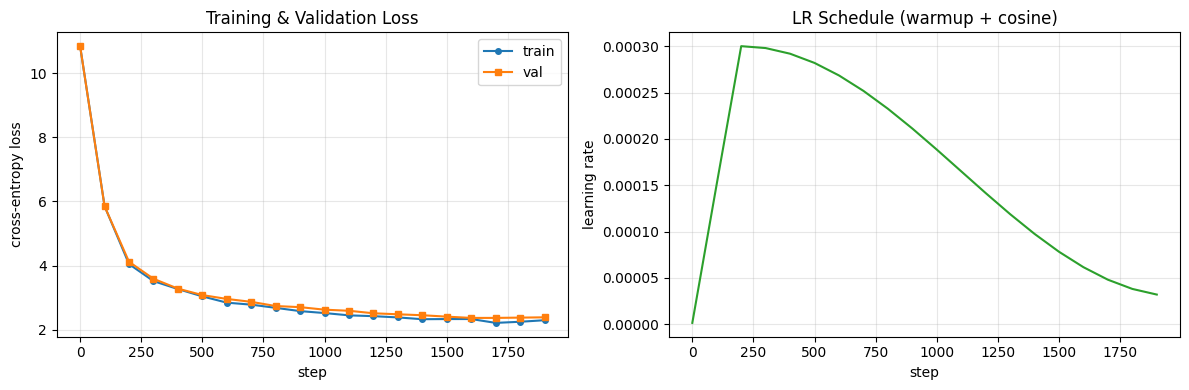

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['step'], history['train_loss'], label='train', marker='o', markersize=4)
ax1.plot(history['step'], history['val_loss'],   label='val',   marker='s', markersize=4)
ax1.set_xlabel('step')
ax1.set_ylabel('cross-entropy loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['step'], history['lr'], color='tab:green')
ax2.set_xlabel('step')
ax2.set_ylabel('learning rate')
ax2.set_title('LR Schedule (warmup + cosine)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("assets/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.5 Generation with temperature + top-k sampling

- **Temperature** $\tau$: rescales logits before softmax — $p_i \propto \exp(z_i / \tau)$. Low $\tau$ → greedy-like. High $\tau$ → diverse but potentially incoherent. We use $\tau = 0.8$.
- **Top-k**: zeroes out everything outside the $k$ highest-probability tokens before sampling, blocking the long tail of rare tokens from occasionally derailing the output. We use $k = 50$.

Together these give a good coherence-diversity trade-off. On TinyStories, we expect the model to produce grammatically correct, simple English sentences after only 2000 steps.

In [17]:
def sample(model, prompt: str, max_new_tokens: int = 150,
           temperature: float = 0.8, top_k: int = 50) -> str:
    model.eval()
    ids = enc.encode_ordinary(prompt) if prompt else [enc.eot_token]
    x   = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)
    out = model.generate(x, max_new_tokens=max_new_tokens,
                         temperature=temperature, top_k=top_k, use_cache=True)
    return enc.decode(out[0].tolist())


prompts = [
    "Once upon a time",
    "",
    "Once upon a time, the stock market crashed and",
    "The little robot asked, 'Why am I here?' and nobody answered, so he",
    "Suddenly,",
    "The magic box was completely empty, but inside it there was",
    "The end.",
    "Timmy found a shiny coin. He knew it belonged to his sister, but",
    "The cat looked at the dog. The dog looked at the cat. The cat looked at the dog.",
]

for p in prompts:
    print("=" * 70)
    print(f"PROMPT: {p!r}")
    print("-" * 70)
    print(sample(model, p))
    print()


PROMPT: 'Once upon a time'
----------------------------------------------------------------------
Once upon a time, there was a little girl named Lily. She loved to explore and explore the world around her. One day, she saw a big, furry squirrel with a long wings. The squirrel was very beautiful and it was very pretty. Lily wanted to keep playing with her ball, but it was too cold for her to carry. 

But the squirrel didn't listen and tried to get up, but it was too hard. Lily tried to get up, but it was too late. She was too sad that she couldn't reach the squirrel. 

As a few minutes came to the squirrel, she saw the squirrel's mouth. "I'm trying to take a closer look at me," said Lily. "I'm sorry, I

PROMPT: ''
----------------------------------------------------------------------
<|endoftext|>Once upon a time, there were two friends, Sam and Tom. They had a long, red car that was very slow and fast. Sam and Tom were very happy.

One day, Sam went to the beach with Sam. Sam wanted t

In [18]:
# Compare three sampling regimes on a single prompt
test_prompt = "Once upon a time"
presets = [
    ("near-greedy",  dict(temperature=0.01, top_k=1)),
    ("balanced",     dict(temperature=0.8,  top_k=50)),
    ("high-temp",    dict(temperature=1.2,  top_k=100)),
]

for name, kwargs in presets:
    print(f"\n[{name}]")
    print(sample(model, test_prompt, max_new_tokens=120, **kwargs))



[near-greedy]
Once upon a time, there was a little girl named Lily. She loved to play outside in the garden. One day, she saw a big, shiny rock in the sky. She wanted to climb it, but it was too high. 

Lily asked her mom, "Can I climb the rock?" Her mom said, "Sure, but be careful not to climb the rock." 

Lily was excited to climb the rock and down. She climbed up the rock and down, and down, feeling the wind in her hair. She felt happy and proud of herself for being so brave.

[balanced]
Once upon a time, there was a little girl named Lily. She loved to play outside in the sun and watch the sun warm. One day, she went outside to play. She saw a big bird on the ground. 

"Let's rest in the sun, Lily! Let's go see the birds!" she said.

Lily climbed the tree and reached for the bird to swim. She was very excited and ran away. 

But then, Lily heard a noise. She was the sky and she saw a big, scary bird. Her mommy had caught a big tree.

[high-temp]
Once upon a time, there was a wild 

---
## Discussion
### What affects performance in my setup
In this minimal GPT setup, several key hyperparameters and architectural choices directly impact the model's performance, training dynamics, and the quality of the generated text:

* **Model Size and Depth:** This model has roughly 30M parameters (6 layers, 6 heads, 384 embedding dimension). While small compared to modern LLMs, it has enough capacity to memorize simple vocabulary and learn the basic grammatical structures of the `TinyStories` dataset. Increasing the width (embedding dimension) or depth (number of layers) would allow the model to capture more complex semantic relationships, though it would require more VRAM and increase the risk of overfitting on such a small 10M-token data subset.

* **Context Length (`block_size`):** The context length is set to 256 tokens. This is sufficient for the model to maintain local coherence within a few sentences (e.g., remembering character names and immediate actions). However, if a story exceeds 256 tokens, the model loses access to the beginning of the prompt. Expanding the context length to 512 or 1024 would drastically improve the model's long-term storytelling consistency, though it would scale the attention computation quadratically.

  
* **Training Time and Data Volume:** The model was trained for 2,000 steps, processing roughly 32.8 million tokens. Because the dataset subset contains 10 million tokens, the model trained for less than two full epochs. The validation loss curve indicates that the model has not yet heavily overfit (train and val loss are very close, at ~2.2590 and ~2.3665 respectively). Training for an extended period (e.g., 5,000 steps) or over a larger slice of the `TinyStories` dataset would likely push the validation loss lower, yielding much more coherent and structured text.

  
* **Tokenization Granularity:**  The model uses the GPT-2 BPE tokenizer with a vocabulary of 50,257 tokens, even though the TinyStories corpus is intentionally restricted to a much narrower lexical distribution centered on roughly 1,500 common English words. This mismatch implies that a substantial fraction of the tokenizer vocabulary is underutilized relative to the dataset, while the tied token embedding/output matrix still occupies a large share of the model’s total parameter budget. A smaller tokenizer trained specifically on TinyStories—for example, an 8k subword vocabulary—could therefore improve parameter efficiency by reducing embedding-related capacity and reallocating more of the model budget to the Transformer blocks, where additional depth or width may yield greater gains in contextual and compositional modeling.